# Example 1 &ndash; Simple 2D Simulation

In example demonstrates setting up a simple 2D simulation in both time- and frequency-domains. FrequenSolve is built on a fast frequency-domain solver; it does not yet have any native time-domain propagators but time-domain simulation is supported by simulating many (often hundreds) of discrete frequencies, then applying the inverse Fourier transform. The frequency-domain solver can be remarkably fast and memory-efficient; so fast that time-domain simulation (with hundreds of frequencies) can be competitive, especially for challenging problems with high-contrast, attenuation, topography, and other challenging effects. However, FrequenSolve's approach is unique and effectively leveraging it requires some insight into how it works. That insight will be built up over the course of these examples.

## Creating a Project

Projects are the highest level container in FrequenSolve; `Project.path` specifies the working directory. A project configuration file will be created under `[Project.path]/[Project.name].json`; this is used to track (and migrate) FrequenSolve versions and can be used to load the project. An optional 'pretty' name can also be specified to be used for autogenerating reports, etc.. 

Each project can contain multiple simulations. Simulation attributes `name`, `dimension`, and `physics` should be provided at initialization; note that `name` is used in the path heirarchy of the project. A Seismic simulation has other required attributes including:

- `model`
- `mesh`
- `BCs`
- `discretization`
- `solver`
- `outputs`
- `acquisition`

These will be defined in subsequent sections.

In [1]:
import numpy as np
from frequensolve import *

project_path = "./scratch/ex_01/"
project = Project(
    name = "project",
    pretty_name = "Simple Simulation",
    path = project_path,
    load_if_exists = False,
)

sim = SeismicSimulation(
    name = "simulation_01",
    physics = "acoustic",
    dimension = 2,
)
project += sim

## Defining a Model

Models can be defined a few different ways in FrequenSolve. In this example we'll use the `LayeredModel` class; this builds a layered model from a collection of non-intersecting simple surfaces sandwiching material 'layers' that specify the velocity model. In 2D simulations, a `LayeredModel` is initialized by specifying the x-limits of the model; the z-limits will be implied by the model surfaces. Surfaces must be defined at the top and bottom of the model, as well as between layers. 

For now, we'll build a simple model composed two homogeneous layers separated by a simple flat interface. Supported material properties include:
- __*Vp*__: Compressive velocity
- __*Qp*__: Compressive quality factor
- __*Vs*__: Shear velocity
- __*Qs*__: Shear quality factor
- __*Rho*__: Density

FrequenSolve supports general anisotropy and various parameterizations, API support for these will be added in the near future. For now, we will assume velocity is specified in *km/s* and density in *g/cm^3*.

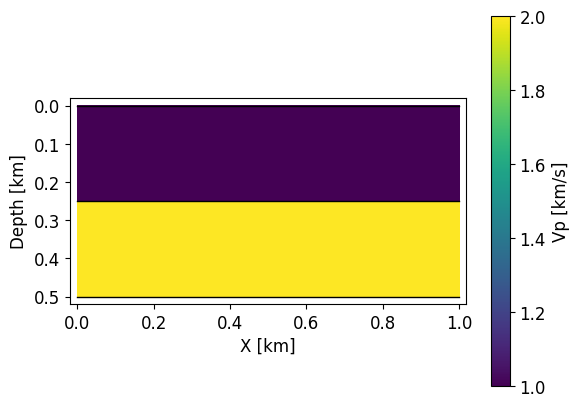

In [2]:
# New 2D layered model over interval x in [0,1]
model = LayeredModel(
    dimension = 2, 
    x_limits = [0.0, 1.0],
)

model.add_surface(name = "top", z = 0.0)

model.add_layer(
    name = "layer_1",
    properties = { 
        "Vp" : 1.0,
        "Qp" : 300.0,
        "Rho": 1.0,
    }
)
model.add_surface(name = "interface", z = 0.25)

model.add_layer(
    name = "layer_2",
    properties = { 
        "Vp" : 2.0,
        "Qp" : 50,
        "Rho": 1.0,
    }
)
model.add_surface(name = "bottom", z = 0.5)

model.plot("Vp", aspect = "equal")
sim += model

## Meshing

As a finite element method, FrequenSolve operates on a computational mesh. FrequenSolve uses a two-step meshing process:

1. An initial mesh is defined via built-in `MeshGenerators`.
2. Advanced adaptive mesh refinement is used to optimize the mesh for each simulation and frequency. 

Adaptive mesh refinement produces a heirarchy of meshes that are used to solve the frequency-domain problem efficiently. This is an important point, the goal of initial mesh generation is *not* to produce accurate meshes that can accurately resolve waves *nor* is it to accurately capture curvilinear geometries (these are the responsibility of the subsequent adaptive mesh refinement); __*the goal of initial mesh generation is to provide a coarse space for the solver*__. A good target is often ~8 &ndash; 32 elements in each direction.

The `LayeredModel` class has a `hex_mesh_generator` method that produces a quad (2D) or hex (3D) mesh that conforms to layers. External tools can also be used to generate an initial mesh, but many tools discard information about surfaces, etc.; mesh refinements will thus be unable to adapt to curvilinear features.

Note that currently, mesh generation is done in the solver code; we simply pass the informtation needed to generate the mesh to the solver.

In [3]:
# Define a Hex mesh generator
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh
sim.mesh.set_adapt(
    min_epw = 1.0,
    adapt_sources = 1,
)

## Boundary Conditions

Boundary Conditions are managed by the `BoundaryConditionManager` class. Boundaries can either be identified via geometry (`label_type = "geometric"`) or defined in the mesh (`label_type = "labeled"`). The API currently supports the following boundary condition types (additional boundary conditions can be added as required):

- `'dirichlet'`:              Fixed pressure/displacement.
- `'neumann'` (free-surface): Fixed normal velocity/traction.
- `'symmetric'`:              Simulates plane symmetry accross the boundary.
- `'pml'`:                    Perfecly matched layer, simulating an absorbing boundary

In [4]:
# New boundery condition manager
BCs = BoundaryConditionManager(
    label_type = "geometric"
)

# Free surface BC
BCs += BoundaryCondition(
    name = "free_surface",
    kind = "neumann",
    boundaries = ["z_min"]
)

# PML boundary condition
BCs += BoundaryCondition(
    name = "pml",
    kind = "pml",
    boundaries = ["x_min", "x_max", "z_max"],
    pml_wavelengths = 1.2,
    pml_exponent = 3.0,
    pml_constant = 10.0
)
sim += BCs

## Defining an Acquistion

The `Acquisition` class stores information about source and receiver locations, type, etc.. Currently, all sources in an acquisition will be batched and solved in a single group. We also assume that receiver positions do not vary over sources. In the future we intend to define additional classes to manage entire surveys with many sources and receivers varying by source; we will then extract and solve groups of nearby sources and allow receiver position to be source dependent. For now, memory constraints often require limiting the number of sources in a group to <100. If more sources are required, additional `Simulation`s can be used to separate the sources into more managable groups.

### Sources
FrequenSolve supports `'scalar'` and `'vector'` sources in acoustic domains, and `'vector'` and `'moment'` sources in elastic domains:

- For `'scalar'` sources, `'direction'` is a scalar array (one entry) that scales the amplitude. 
   - 2D & 3D: `[ A ]`
- For `'vector'` sources, `'direction'` is an array providing the direction and amplitude of the source.
   - 2D: `[ f_x, f_z ]`
   - 3D: `[ f_x, f_y, f_z ]`
- Finally, for `'moment'` sources, `'direction'` is a rank-2 tensor given in Voigt notation.
   - 2D: `[ M_xx, M_yy, M_xy ]`
   - 3D: `[ M_xx, M_yy, M_zz, M_yz, M_xz, M_xy ]`

### Receivers
FrequenSolve supports multicomponent recievers and various receiver types designed to facilitate integration of measurments from diverse site instrumentation. Receivers combine the `ReceiverDevice`, which defines the measurement type and component, with spatial data about the location of devices. Supported `ReceiverDevice`s include:

- `RecieverNode`: A single-node sensor, recording point measurements.
- `RecieverNodeArray`: A single-channel array of nodes, recording average point measurements over the array.
- `RecieverFiber`: DAS fiber (straight or helical), integrating tangential responses over a 1-D length.

The `coords` argument below specifis the coordinates of the reciever. It can be defined a number of ways, including via numpy/xarray arrays, via files, and via a regular grid of points. See `ReceiverCoordinates` and its derived classes for more information.

In [5]:
acq = Acquisition()

# Sources
acq.add_source_group(
    kind = "scalar",
    coords = [ [x, 0.0] for x in np.linspace(0.0, 1.0, 1)],
    frame = "reference"
)

# Hydrophones
hydrophone = ReceiverNode(name = "hydrophone")
hydrophone.add_component(
    name = "p",
    field = "pressure",
)

coords = [ [x, 0.0] for x in np.linspace(0.0, 1.0, 1001) ]
acq.add_receiver_group(
    name = "surface_hydrophones",
    device = hydrophone,
    coords = coords,
    frame = "reference"
)

# Add acquisition to the simulation
sim += acq

## Discretization

The `Discretization` class be set defines a few last aspects of the numerical method. FrequenSolve primarily leverages the discontinuous Petrov&ndash;Galerkin finite element method, you can read about the DPG method more in the Theory section of the documentation **TODO**. Of the attributes defined in `Discretization`, the only one we need to worry about at this point is the `order`. This controls the order of approximation; it's default value is 3 but orders 4&ndash;6 often work well in 2D (in 3D, order 3&ndash;4 is usually a good place to start).

In [6]:
method = Discretization(order = 6)
sim += method

solver = SolverConfig(
    solve_on = "final",
    max_iter = 300,
    tolerance = 1.0e-4
)
sim += solver

## Outputs

Finally, we define the outputs of the simulation. We'll start with a Paraview output **TODO: Change this once other plotting methods have been implemented; ParaView is too cumbersome for beginners**

In [7]:
out = OutputManager()
out += ParaviewOutput(
    name = "simple", 
    fields = ["pressure"],
    upscale = 1,
)
sim += out

Before moving on we'll save the project, this writes a `project.json` file in the project directory. This file can be used to load the project later. Note that saving the project is required before simulations can be run.

In [8]:
project.save()

# Deleting project not necessary, for illustration only
del project
project = Project.load("scratch/ex_01/project.json")

## Running a Simulation

We'll start with an acoustic 2D simulation. The `Simulation` class has all it needs to run a simulation except for the frequency (or, for time-domain simulation, the frequencies). 


  ooooo                                         .oPYo.        8
  8                                             8             8
  8oo   oPYo. .oPYo. .oPYo. o    o .oPYo. odYo. `Yooo. .oPYo. 8 o    o .oPYo.
  8     8  `' 8oooo8 8    8 8    8 8oooo8 8' `8     `8 8    8 8 Y.  .P 8oooo8
  8     8     8.     8    8 8    8 8.     8   8      8 8    8 8 `b..d' 8.
  8     8     `Yooo' `YooP8 `YooP' `Yooo' 8   8 `YooP' `YooP' 8  `YP'  `Yooo'
                          8
                          8


 Copyright (c) 2023-2025 Jacob Badger, FrequenSol LLC -- All Rights Reserved

   This proprietary software is only available to authorized individuals,
   if you encounter this message and do not have a license, please contact
   the copyright holders (Jacob Badger <jacob.badger@frequensol.com>)


 Greetings master.

 -- Parallelism -- 
 Ranks  :    1
 Threads:   16

 -- BCs -- 
 face, BC: 1 Neumann
 face, BC: 2 PML
 face, BC: 3 PML
 face, BC: 4 PML

 -- Hex Mesh -- 
 # elems:       6       3

 recei

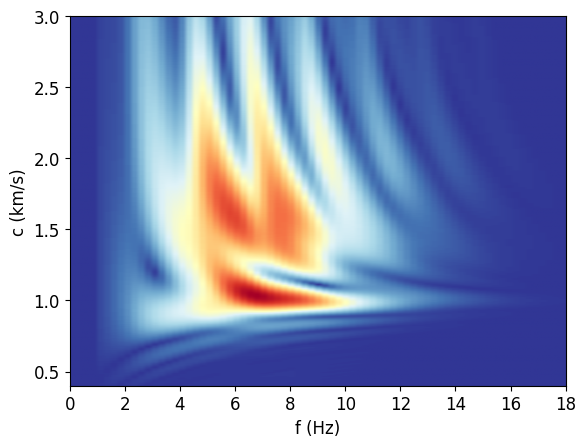

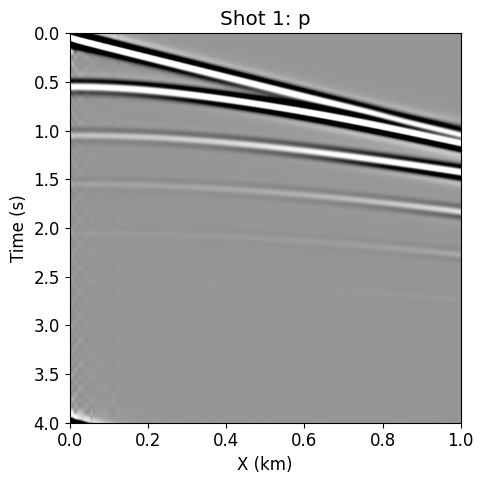

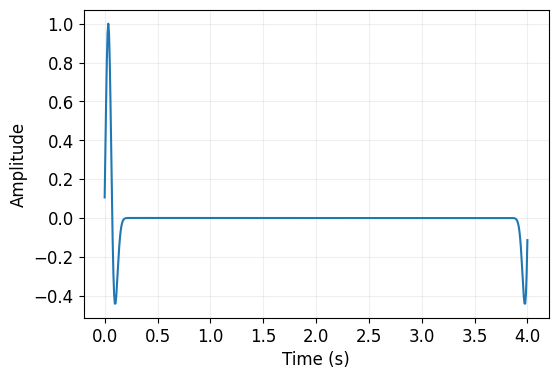

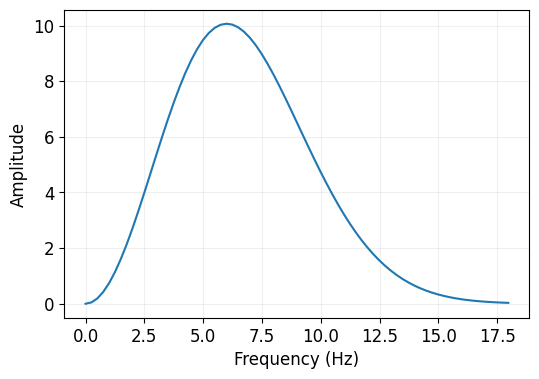

In [9]:
# --- Connect to site ---
   
site = "stampede3"

if site == "local":
    site = LocalSite()
elif site == "stampede3":
    site = Stampede3Site(
        rel_path = "problems/ex_01/",
        default_queue = "skx-dev"
    )
else:
    raise ValueError(f"Site {site} not supported; specify a valid site from options above.")

site.sync(project)

# Define and submit a time-domain simulation
td_job = TimeDomainJob(
    name = "time",
    simulation = sim,
    f_min = 1.0,
    f_max = 18.0,
    T_max = 4.0
)

if site.provisioned:
    site.submit(td_job)
else:
    site.submit_SLURM(
        job = td_job,
        nodes = 1,
        procs_per_node = 12,
        procs_per_task = 1,
        queue = "skx-dev",
        duration = "00-00:01:00",
    )

    # Wait for SLURM job to complete
    site.wait_completion(td_job)

# Get results from the site
trace_db = site.fetch_traces(td_job, upscale = 4)
wavelet = RickerWavelet(
    f0 = 6.0,
    times = trace_db.times(), 
    offset = 5
)

for record in trace_db:
    shot = record.read_FD(wavelet)
    plot_cf(shot, c_min = 0.4, c_max = 3.0, n_c = 400)
    
    shot = record.read_TD(wavelet)
    plot_gather(shot, A = 100)
    
wavelet.plot()